First 5 Rows
   Page Views  Session Duration  Bounce Rate Traffic Source  Time on Page  \
0           5         11.051381     0.230652        Organic      3.890460   
1           4          3.429316     0.391001         Social      8.478174   
2           4          1.621052     0.397986        Organic      9.636170   
3           5          3.629279     0.180458        Organic      2.071925   
4           5          4.235843     0.291541           Paid      1.960654   

   Previous Visits  Conversion Rate  
0                3              1.0  
1                0              1.0  
2                2              1.0  
3                3              1.0  
4                5              1.0  

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Page Views        2000 non-null   int64  
 1   Session Duration  2000 

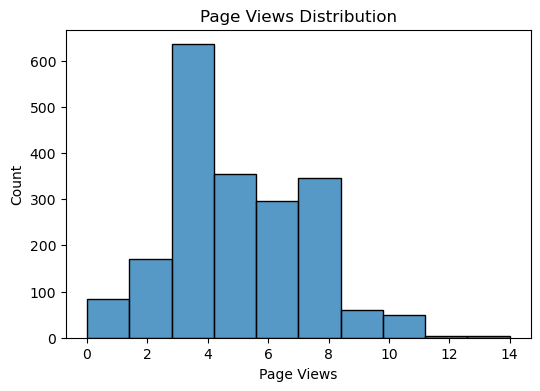

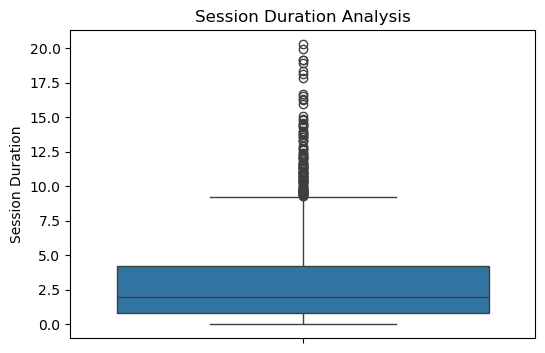

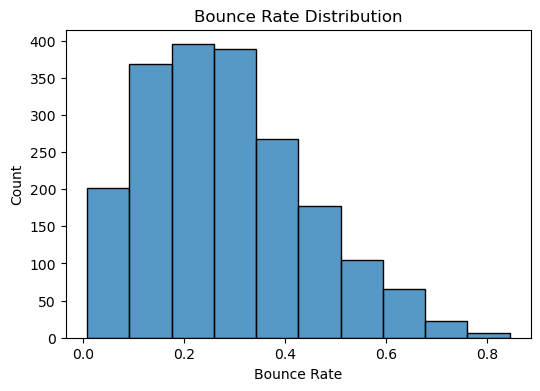

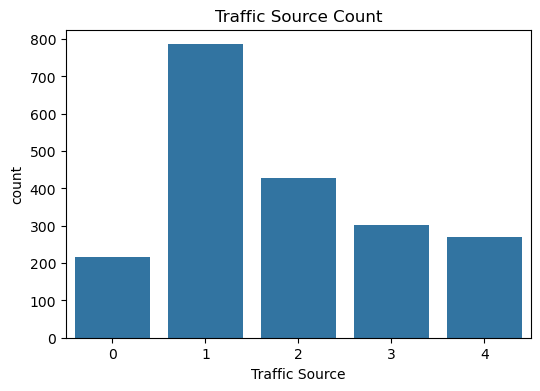

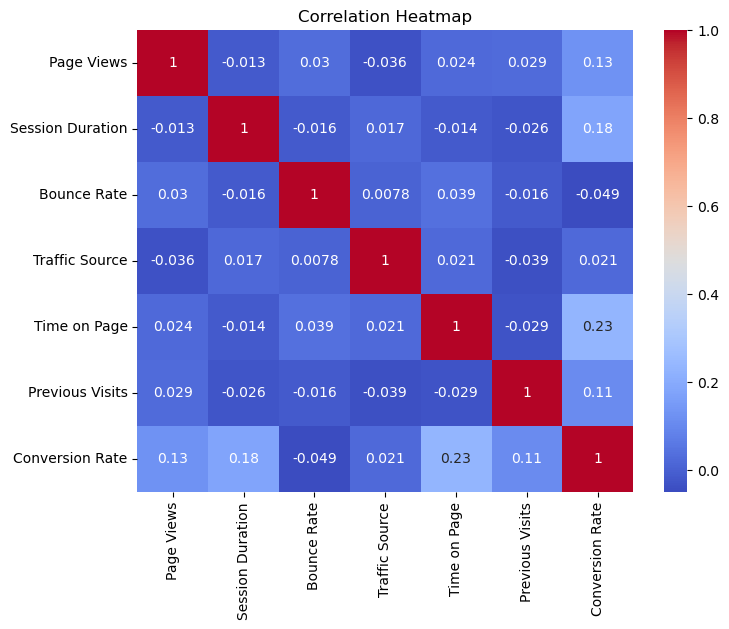


Model Evaluation
Mean Absolute Error:
0.03150270463770159

R2 Score:
0.10924421130571726

Feature Importance
            Feature  Importance
0        Page Views    0.003386
1  Session Duration    0.003999
2       Bounce Rate   -0.027165
3    Traffic Source    0.001041
4      Time on Page    0.005606
5   Previous Visits    0.005282

Web Traffic Analytics Project Completed Successfully!


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("website_wata.csv")
print("First 5 Rows")
print(df.head())
print("\nDataset Information")
print(df.info())
print("\nColumn Names")
print(df.columns)
print("\nMissing Values")
print(df.isnull().sum())
df.dropna(inplace=True)
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

print("\nEncoded Dataset")
print(df.head())
plt.figure(figsize=(6,4))
sns.histplot(df["Page Views"], bins=10)
plt.title("Page Views Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(y=df["Session Duration"])
plt.title("Session Duration Analysis")
plt.show()


plt.figure(figsize=(6,4))
sns.histplot(df["Bounce Rate"], bins=10)
plt.title("Bounce Rate Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x="Traffic Source", data=df)
plt.title("Traffic Source Count")
plt.show()


plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


X = df.drop("Conversion Rate", axis=1)
y = df["Conversion Rate"]

# Step 9 - Split Dataset
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 10 - Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

# Step 11 - Prediction
y_pred = model.predict(X_test)

# Step 12 - Evaluation
from sklearn.metrics import mean_absolute_error, r2_score

print("\nModel Evaluation")

print("Mean Absolute Error:")
print(mean_absolute_error(y_test, y_pred))

print("\nR2 Score:")
print(r2_score(y_test, y_pred))

# Step 13 - Feature Importance
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.coef_
})

print("\nFeature Importance")
print(importance)

# Step 14 - Save Cleaned Dataset
df.to_csv("cleaned_web_traffic.csv", index=False)

print("\nWeb Traffic Analytics Project Completed Successfully!")